# Этап 1. Работа с данными и демонстрация работы сырой модели

In [1]:
import os
import requests
import torch
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from diffusers import StableDiffusionPipeline

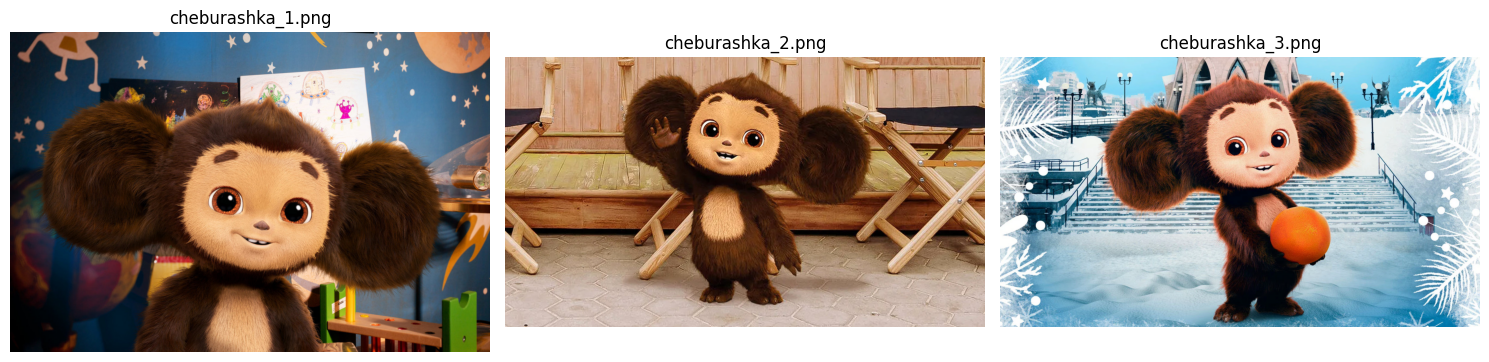

In [2]:
def download_dataset():
    """Скачивание датасета с чебурашкой"""
    os.makedirs("dataset", exist_ok=True)
    urls = [
        "https://code.s3.yandex.net/deep-learning/cheburashka_1.png?etag=c5d0692223b9a83575ef4ccee9679c54",
        "https://code.s3.yandex.net/deep-learning/cheburashka_2.png?etag=dc3c5bb94cd1571c0ce7cc5a540500ab",
        "https://code.s3.yandex.net/deep-learning/cheburashka_3.png?etag=3bd86d39bacaf6d71daa580b676212fa"
    ]
    image_paths = []
    for i, url in enumerate(urls):
        path = f"dataset/cheburashka_{i+1}.png"
        if not os.path.exists(path):
            print(f"Скачивание {path}...")
            resp = requests.get(url)
            with open(path, "wb") as f:
                f.write(resp.content)
        image_paths.append(path)
    return image_paths

def visualize_dataset(image_paths):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for idx, path in enumerate(image_paths):
        img = Image.open(path).convert("RGB")
        axes[idx].imshow(img)
        axes[idx].axis("off")
        axes[idx].set_title(os.path.basename(path))
    plt.tight_layout()
    plt.show()

image_paths = download_dataset()
visualize_dataset(image_paths)

## Реализация класса датасета

In [3]:
class CheburashkaDataset(Dataset):
    def __init__(self, image_paths):
        self.image_paths = image_paths
        # Ресайз к 512x512, преобразование в тензор и нормализация (-1 до 1) 
        # Mean 0.5 и Std 0.5 переводит [0, 1] в [-1, 1] -- стандарт для SD1.5
        self.transform = T.Compose([
            T.Resize((512, 512)),
            T.ToTensor(),
            T.Normalize([0.5], [0.5])
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img)

In [4]:
dataset = CheburashkaDataset(image_paths)
print(f"Создан датасет размером: {len(dataset)}")
sample_tensor = dataset[0]
print(f"Форма тензора первого элемента: {sample_tensor.shape}\n")

Создан датасет размером: 3
Форма тензора первого элемента: torch.Size([3, 512, 512])



## Работа с оригинальной моделью

In [5]:
print("Загрузка модели Stable Diffusion 1.5...")
# Используем fp16. Для 1080Ti на 11 ГБ этого более чем достаточно,
# SD 1.5 весит ~3-4 ГБ в видеопамяти при dtype=float16.
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

=== ЭТАП 2: Работа с моделью ===
Загрузка модели Stable Diffusion 1.5...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /home/bogatp/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /home/bogatp/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Генерация с сырой моделью

Генерация тестового изображения по промпту: '<cheburashka> with the Eiffel Tower in the background'...


  0%|          | 0/30 [00:00<?, ?it/s]

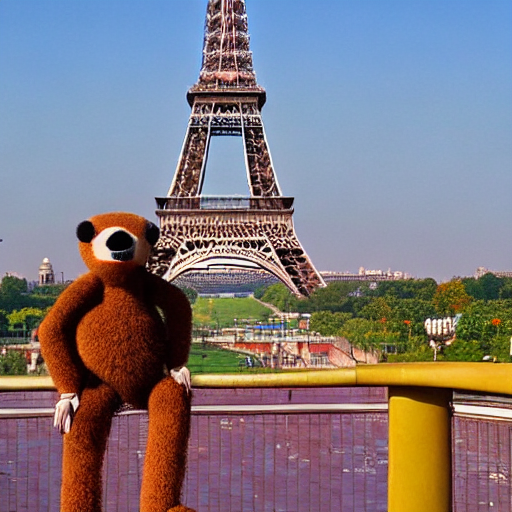

In [7]:
prompt = "<cheburashka> with the Eiffel Tower in the background"
print(f"Генерация тестового изображения по промпту: '{prompt}'...")
# Генерируем всего одну картинку
raw_image = pipe(prompt=prompt, num_inference_steps=30).images[0]
display(raw_image)

## Извлекаем текстовые эмбеддинги

In [8]:
print("Исследование функции encode_prompt и извлечение эмбеддингов...")
target_prompt = "<cheburashka> plushie"
target_device = pipe.device

Исследование функции encode_prompt и извлечение эмбеддингов...


## Вызываем encode_prompt. 

In [9]:
# Вызываем encode_prompt. 
# Возвращает кортеж (prompt_embeds, negative_prompt_embeds)
prompt_embeds, negative_prompt_embeds = pipe.encode_prompt(
    prompt=target_prompt,
    device=target_device,
    num_images_per_prompt=1,
    do_classifier_free_guidance=False
)

torch.save(prompt_embeds, "cheburashka_embeds.pt")
print(f"Текстовые эмбеддинги для промпта '{target_prompt}' сохранены в 'cheburashka_embeds.pt'")
print(f"Форма сохраненного тензора: {prompt_embeds.shape}")

print("\n--- Phase 1 завершена успешно ---")

Текстовые эмбеддинги для промпта '<cheburashka> plushie' сохранены в 'cheburashka_embeds.pt'
Форма сохраненного тензора: torch.Size([1, 77, 768])

--- Phase 1 завершена успешно ---
